# Labwork 2

In [4]:
# Load data
with open("lr.csv", "r") as f:
    data = f.readlines()
    
x = []

for row in data:
    a, b = row.replace("\n","").split(',')
    x.append([float(a), float(b)])

# f(x0,x1) = w0.x0 + w1.x1
lr = 0.5
def gradient_descent(w0, w1, x0, x1):
    w0 = w0 - lr * x0
    w1 = w1 - lr * x1
    
    return w0, w1

def show_table(epochs, w0, w1, data, eps=0.1):
    print(f"-"*40)
    print(f"Time\tw0\tw1\tf(x)")
    
    for i in range(epochs):
        f_x = data[i][0] * w0 + data[i][1] * w1
        w0, w1 = gradient_descent(w0,w1,data[i][0],data[i][1])
        print(f"{i+1}\t{w0:.2f}\t{w1:.2f}\t{f_x:.2f}")
        

show_table(10, 0,0,x)

----------------------------------------
Time	w0	w1	f(x)
1	-5.00	-27.50	0.00
2	-15.00	-67.50	-2300.00
3	-35.00	-117.50	-7350.00
4	-65.00	-177.50	-16200.00
5	-105.00	-252.50	-31825.00


IndexError: list index out of range

## Extra 

In [5]:
def process_dtype(raw):
    data = []
    for line in raw:
        line = line.replace("\n","").split(',')
        data.append([float(line[i]) for i in range(len(line))])
        
    return data

def load_data(path, header=True):
    with open(path, "r") as f:
        lines = f.readlines()
    data = process_dtype(lines[1:]) if header else process_dtype(lines)
    
    x, y = [], []
    for s in data:
        y.append(s[-1])
        x_i = s[:len(s)-1]
        x.append(x_i) if len(x_i)>1 else x.extend(x_i)
    
    return x, y

def cal_loss(y_pred, y_true):
    loss = 0
    n = len(y_true)
    
    for y_t, y_p in zip(y_true, y_pred):
        loss += (y_t - y_p)*(y_t - y_p)
        
    return (1/2) * (1/n) * loss 

def run(lr, x, y_true, epochs = 10, eps=0.01):
    w = [1.0, 0.0]
    losses = []

    for e in range(epochs):
        w0, w1 = w[0], w[1]
        y_pred = []
        
        for i in range(len(x)):
            pred = w[0]*x[i] + w[1]
            y_pred.append(pred)
            w[0] = w[0] - lr * x[i] * (pred - y_true[i])
            w[1] = w[1] - lr * (pred - y_true[i])
        
        loss = cal_loss(y_pred,y_true)
        
        if len(losses) > 0 and abs(loss-losses[-1]) < eps:
            losses.append(loss)
            break
        losses.append(loss)    
        
        print(f"Epoch {e+1}: Loss = {loss}")
    return w
    
    

In [6]:
data_path_loan = r"./loan2.csv" 
data_path_lr = r"./lr.csv"
x, y = load_data(data_path_lr, header=False)
x

[10.0, 20.0, 40.0, 60.0, 80.0]

In [18]:
lr = 0.0001
epochs = 10000
w = run(lr,x, y, epochs)

Epoch 1: Loss = 1025.0266677140226
Epoch 2: Loss = 396.4881373162634
Epoch 3: Loss = 358.3248588141998
Epoch 4: Loss = 353.84809719285846
Epoch 5: Loss = 353.034495724266
Epoch 6: Loss = 352.80875797838934
Epoch 7: Loss = 352.68820308110656
Epoch 8: Loss = 352.5869053558149
Epoch 9: Loss = 352.4891662152552
Epoch 10: Loss = 352.3921034929977
Epoch 11: Loss = 352.2951875582398
Epoch 12: Loss = 352.198321063953
Epoch 13: Loss = 352.1014861118323
Epoch 14: Loss = 352.0046794058503
Epoch 15: Loss = 351.9079003338256
Epoch 16: Loss = 351.81114877685934
Epoch 17: Loss = 351.7144247067183
Epoch 18: Loss = 351.6177281118348
Epoch 19: Loss = 351.5210589837065
Epoch 20: Loss = 351.4244173143956
Epoch 21: Loss = 351.3278030960709
Epoch 22: Loss = 351.2312163209213
Epoch 23: Loss = 351.1346569811426
Epoch 24: Loss = 351.03812506893235
Epoch 25: Loss = 350.94162057649123
Epoch 26: Loss = 350.8451434960222
Epoch 27: Loss = 350.7486938197296
Epoch 28: Loss = 350.65227153982073
Epoch 29: Loss = 350.55

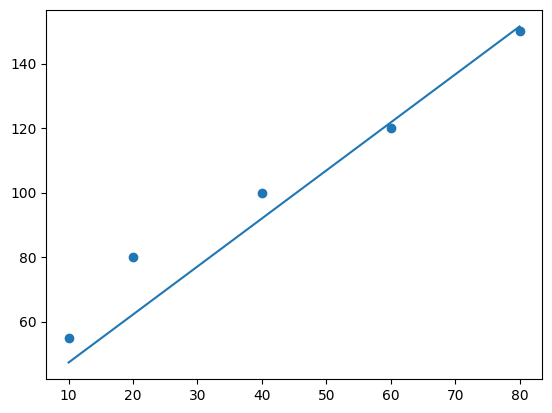

In [19]:
import matplotlib.pyplot as plt

predict = []
for d in x:
    predict.append(w[0] * d + w[1])
plt.scatter(x, y)
plt.plot(x,predict)
plt.show()